# 02 · Exploratory Data Analysis

**Notebook:** 02 of 04  
**Goal:** Discover patterns in the data through bivariate and multivariate analysis.

### What this notebook covers
- Bivariate analysis: each feature vs. the Return target
- Multivariate analysis: combined feature interactions
- Final business recommendations based on findings

In [23]:
import pandas as pd
import numpy as np
import plotly.express as px

# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

In [24]:
import pandas as pd

# ── Load cleaned data from notebook 01 ───────────────────────────────────────
df = pd.read_csv("data/01_cleaned.csv")
print(f"Loaded data → shape: {df.shape}")
df.head(3)

Loaded data → shape: (19504, 17)


,Month,product_category,Product_Subcategory,Quantity,Unit_Price,Price,Tax,Payment_mode,Store_type,Reviews,Income,city,Gender,Marital_status,Education_Level,Profession_Type,Return
0,January,Books,Fiction,3,359,1077,188.475,Mobile Payments,e-Shop,1.0,67501.0,Hyderabad,M,0,PhD,Others,1
1,January,Clothing,Women,5,1129,5645,592.725,Credit Card,TeleShop,1.0,102738.0,Bangalore,M,1,Master,Salaried,1
2,January,Home and kitchen,Bath,4,1327,5308,696.675,Debit Card,MBR,1.0,104013.0,Kolkata,M,1,Basic,Salaried,1


# baivariate analysis

## 1- Does Payment mode affect the return rate?

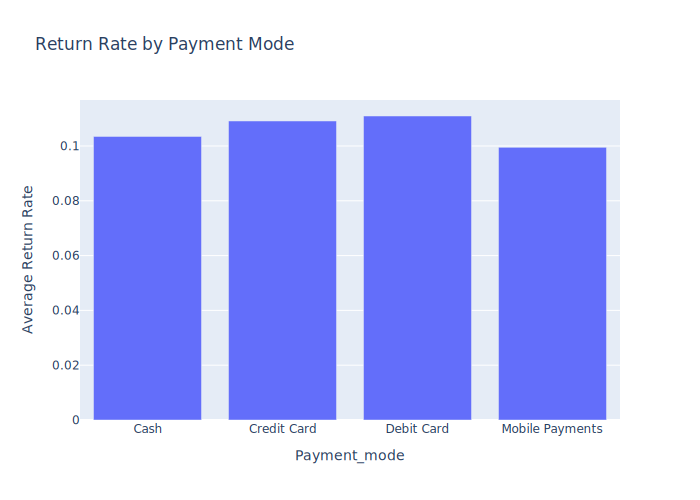

In [25]:
return_by_payment = df.groupby('Payment_mode')['Return'].mean().reset_index()

fig = px.bar(return_by_payment, x='Payment_mode', y='Return',
             title='Return Rate by Payment Mode',
             labels={'Return': 'Average Return Rate'})
fig.show()


### Insight Summary:

#### - **The effect of payment mode on returns seems weak because the differences are small (only about 2% between Credit Card and others).**

## 2- Does the Store type influence returns?

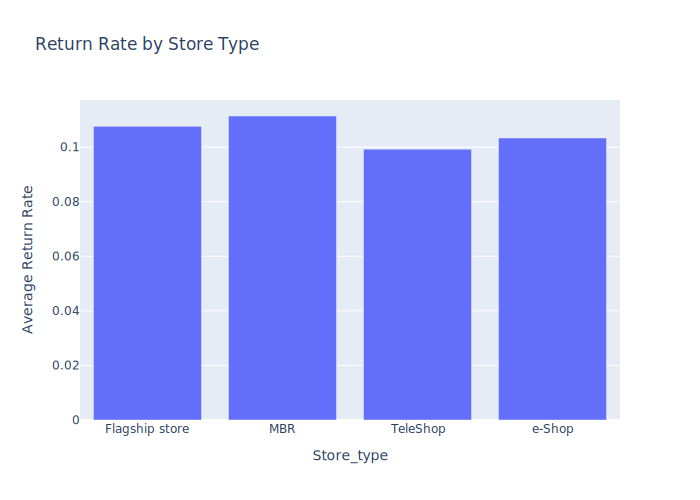

In [26]:
return_by_store = df.groupby('Store_type')['Return'].mean().reset_index()

fig = px.bar(return_by_store, x='Store_type', y='Return',
             title='Return Rate by Store Type',
             labels={'Return': 'Average Return Rate'})
fig.show()


In [27]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

## 3- Does Income level influence return behavior?

In [28]:
df.Income.describe()

count     19504.000000
mean      70516.888074
std       37418.384648
min        7157.000000
25%       37950.000000
50%       69293.000000
75%       99534.000000
max      159984.000000
Name: Income, dtype: float64

In [29]:
# Create income category bins
bins = [0, 38000, 69000, 99000, df['Income'].max()]
labels = ['Low', 'Medium', 'High', 'Very High']

df['Income_Category'] = pd.cut(df['Income'], bins= bins, labels= labels, include_lowest=True)


df['Income_Category'].value_counts()

Income_Category
Very High    4972
Low          4885
High         4828
Medium       4819
Name: count, dtype: int64

/var/folders/0f/sg0d5c153zv11896v810g2_80000gn/T/ipykernel_46681/3241298616.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



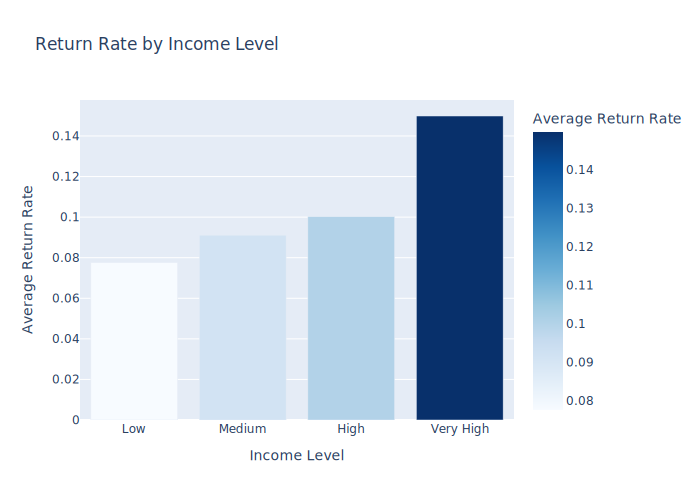

,Income_Category,Return
0,Low,0.077584
1,Medium,0.091098
2,High,0.100249
3,Very High,0.149839


In [30]:
return_by_income = df.groupby('Income_Category')['Return'].mean().reset_index()

fig = px.bar(return_by_income,
             x='Income_Category',
             y='Return',
             title='Return Rate by Income Level',
             labels={'Return': 'Average Return Rate', 'Income_Category': 'Income Level'},

             color='Return',
             color_continuous_scale='Blues')
fig.show()

return_by_income

### - Insight Summary:

- 1- **Very High income level has the highest return rate at 0.14 (14% returned), much higher than the others**

- 2- **The effect of income on returns is strong because Very High income people return a lot more than others.**


### - Recommendation Summary:

- **1- Focus on why Very High income customers return items—maybe they buy expensive things and change their minds.**

- **2- Check if product quality or store service needs improvement for high-income shoppers**

## 3- What is Return Rate of products in each Category?




In [31]:
# Calculate average return rate by product category and subcategory
return_by_category = (
    df.groupby(['product_category', 'Product_Subcategory'])['Return']
      .mean()
      .reset_index()
      .sort_values('Return', ascending=False)
)

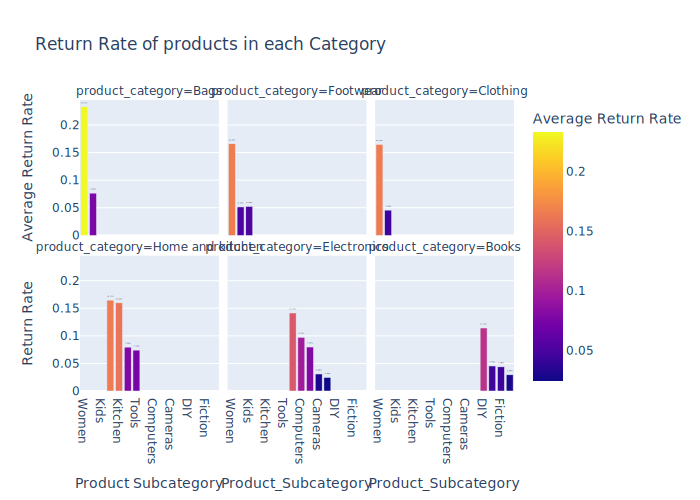

,product_category,Product_Subcategory,Return
1,Bags,Women,0.233103
15,Footwear,Women,0.165912
7,Clothing,Women,0.164884
17,Home and kitchen,Furnishing,0.164731
18,Home and kitchen,Kitchen,0.159868
11,Electronics,Mobiles,0.141447
3,Books,DIY,0.114241
10,Electronics,Computers,0.097264
12,Electronics,Personal Appliances,0.079734
16,Home and kitchen,Bath,0.079532


In [32]:
# Faceted bar chart
fig = px.bar(
    return_by_category,
    x='Product_Subcategory',
    y='Return',
    color='Return',
    facet_col='product_category',
    facet_col_wrap=3,  # Adjust number of columns shown per row
    title='Return Rate of products in each Category',
    labels={'Return': 'Average Return Rate'},
    text='Return'
)

# Beautify layout
fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.update_layout(
    xaxis_title='Product Subcategory',
    yaxis_title='Return Rate',
    height=800,
    showlegend=False
)

fig.show()
return_by_category

### - Insight Summary:

- **1- In the Bags, Footwear, and Clothing categories, Women’s products have a high return rate above 17%, much higher than Men’s products, suggesting a specific issue with women’s items.**

- **2- In the Home and Kitchen category, Kitchen and Furnishing subcategories show significant returns at 15-16%, indicating potential problems in these areas.**

- **3- n the Electronics category, Mobiles have a notable return rate of 14%, pointing to possible quality or usability concerns.**

- **4-In the Books category, DIY stands out with a 12% return rate, higher than other subcategories, suggesting an area needing attention.**

- **5-The effect of gender and subcategory on returns is strong, with women’s products and specific subcategories like Kitchen, Furnishing, Mobiles, and DIY driving higher return rates.**

### - Recommendation Summary:

- **1- For Bags, Footwear, and Clothing, investigate why Women’s products exceed 17% returns—check for sizing issues, fit problems, or quality defects—and improve product design or provide better fitting guides**

- **2- For Electronics, address Mobiles’ 14% return rate with better quality control, improved warranties, or customer support for technical issues.**

- **3- Collect customer feedback during the trial month to understand why they are returning products (e.g., wrong size or poor quality) and
Use the results to improve the products.**

## 4- How does Reviews (customer satisfaction) relate to Return ?

In [33]:
df.Reviews.describe()

count    19504.000000
mean         3.882639
std          1.414655
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Reviews, dtype: float64

In [34]:
def categorize_review(x):
    if x <= 2:
        return 'Low'
    elif x == 3:
        return 'Medium'
    else:
        return 'High'

df['Review_Level'] = df['Reviews'].apply(categorize_review)

df.Review_Level.value_counts()

Review_Level
High      14204
Low        4021
Medium     1279
Name: count, dtype: int64

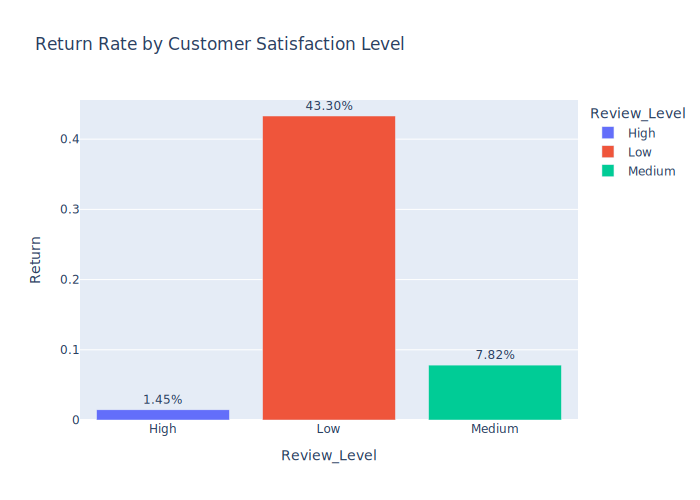

In [35]:
# Calculate return rate by review level
review_return = df.groupby('Review_Level')['Return'].mean().reset_index()

# Plot interactive chart
fig = px.bar(
    review_return,
    x='Review_Level',
    y='Return',
    color='Review_Level',
    title='Return Rate by Customer Satisfaction Level',
    text='Return',
)

fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.show()


### - Insight Summary:

-  **1- Low satisfaction level has the highest return rate at 0.43 (43% returned), much higher than the average.**

-  **1- The effect of satisfaction level on returns is strong because low satisfaction leads to a lot more returns than high or medium..**


### - Recommendation Summary:

- **1- Focus on improving satisfaction for customers with low reviews to reduce returns.**


## **4- Does the tax amount (Low / Medium / High) influence whether a product is returned?**

In [36]:
df.Tax.describe()

count    19504.000000
mean       241.235454
std        182.887380
min          7.350000
25%         95.760000
50%        190.785000
75%        349.965000
max        787.500000
Name: Tax, dtype: float64

In [37]:
# Convert the tax column into three categories to see the effect and determine if one category is larger than another

def map_tax(x):
    if x <= 95.76:
        return "Low"
    elif x <= 349.97:
        return "Medium"
    else:
        return "High"

df["Tax_Level"] = df["Tax"].apply(map_tax)

In [38]:
df.Tax_Level.value_counts()

Tax_Level
Medium    9750
Low       4880
High      4874
Name: count, dtype: int64

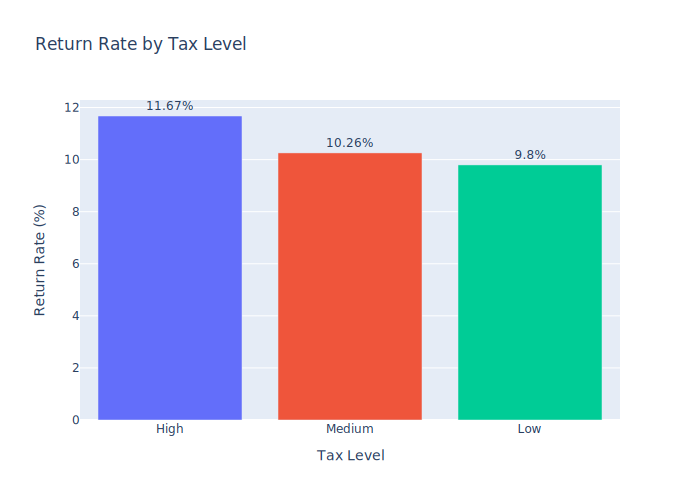

In [39]:
# Calculate mean return rate per tax level
tax_return = df.groupby("Tax_Level")["Return"].mean().reset_index().sort_values("Return", ascending=False)

# Convert to percentage
tax_return["Return"] = tax_return["Return"] * 100

# Plot
fig = px.bar(
    tax_return,
    x= "Tax_Level",
    y= "Return",
    color="Tax_Level",
    text= tax_return["Return"].round(2).astype(str) + '%',
    title= "Return Rate by Tax Level",
    labels= {"Tax_Level": "Tax Level", "Return": "Return Rate (%)"}
)

fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

# Multivariate analysis

## 5- What is the combined effect of Customer Satisfaction Level on returns for Women’s Clothing and Footwear?

#### **- To see if reviews affect returns of women's products that have a high percentage of returns.**

In [40]:
df[['product_category', 'Product_Subcategory']]

,product_category,Product_Subcategory
0,Books,Fiction
1,Clothing,Women
2,Home and kitchen,Bath
3,Footwear,Mens
4,Clothing,Women
...,...,...
19499,Electronics,Audio and video
19500,Bags,Mens
19501,Footwear,Women
19502,Electronics,Mobiles


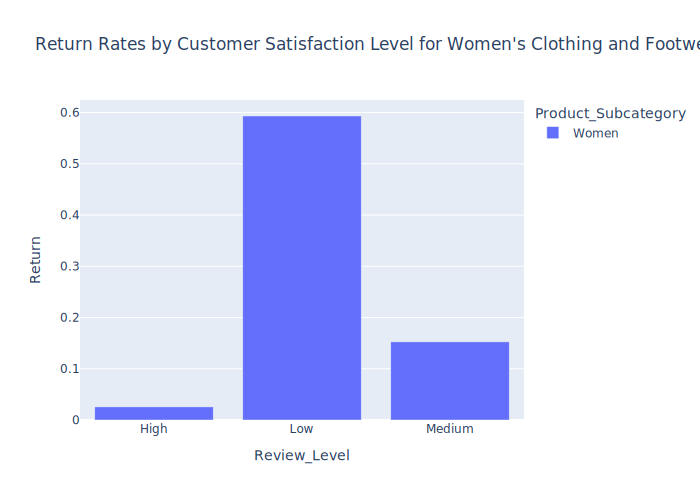

,Product_Subcategory,Review_Level,Return
0,Women,High,0.025557
1,Women,Low,0.593338
2,Women,Medium,0.152493


In [41]:
# Filter for Women’s products
df_women = df[df["Product_Subcategory"] == "Women"]

# Compute return rates by Satisfaction Level and Subcategory
return_analysis = (
    df_women.groupby(["Product_Subcategory", "Review_Level"])["Return"]
    .mean()
    .reset_index()
    .sort_values(by=["Product_Subcategory", "Review_Level"])
)

# Visualize
import plotly.express as px

fig = px.bar(
    return_analysis,
    x="Review_Level",
    y="Return",
    color="Product_Subcategory",
    barmode="group",
    title="Return Rates by Customer Satisfaction Level for Women's Clothing and Footwear",
    labels={"Returned": "Return Rate"},
)
fig.show()

return_analysis


-

## 6- How does Reviews (customer satisfaction) relate to Return for each category

In [42]:
review_return = (
    df.groupby(["product_category", "Reviews"])["Return"]
    .mean()
    .reset_index()
    .sort_values(by=["product_category", "Reviews"])
)

review_return

,product_category,Reviews,Return
0,Bags,1.0,0.669811
1,Bags,2.0,0.352381
2,Bags,3.0,0.125749
3,Bags,4.0,0.045000
4,Bags,5.0,0.020344
5,Books,1.0,0.398406
6,Books,2.0,0.156250
7,Books,3.0,0.020270
8,Books,4.0,0.011706
9,Books,5.0,0.006344


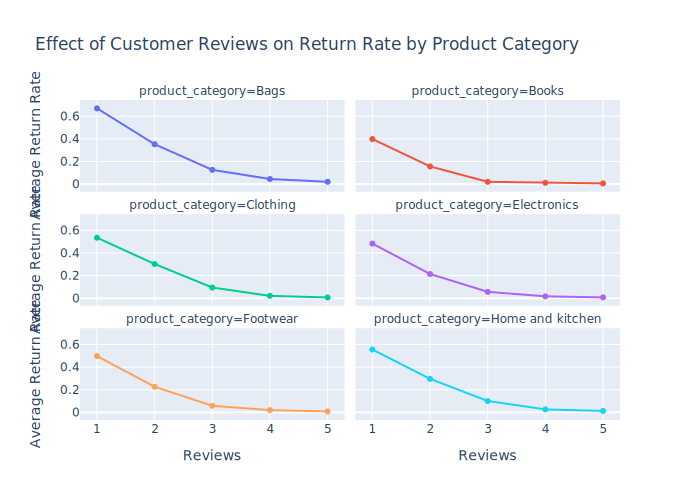

In [43]:
fig = px.line(
    review_return,
    x="Reviews",
    y="Return",
    color="product_category",
    facet_col="product_category",
    facet_col_wrap=2,  # adjust number of columns shown in the grid
    markers=True,
    title="Effect of Customer Reviews on Return Rate by Product Category",
    labels={"Return": "Average Return Rate", "Review": "Customer Review (Satisfaction)"},
)

fig.update_traces(line=dict(width=2))
fig.update_layout(showlegend=False)
fig.show()


### - Insight Summary:

-  **The relationship between Reviews and Return is strong across categories, especially for Women’s products, where low satisfaction significantly boosts returns.**


### - Recommendation Summary:

- **Focus on addressing the 59% return rate for Women’s Clothing and Footwear under low satisfaction by improving product quality or fit.**


## 7- How do Income Level and Product Category interact to affect return rates?

**- Combining them helps identify segments driving high return rates (e.g. wealthy customers returning specific products).**

**- Identify which income ategory combinations have the highest or lowest return rates.**

In [44]:
df['Income_Category'].value_counts()

Income_Category
Very High    4972
Low          4885
High         4828
Medium       4819
Name: count, dtype: int64

In [45]:
#  average return rate by category and income
income_category_return = (
    df.groupby(["Income_Category", "product_category"])["Return"]
    .mean()
    .reset_index()
)


/var/folders/0f/sg0d5c153zv11896v810g2_80000gn/T/ipykernel_46681/225613887.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



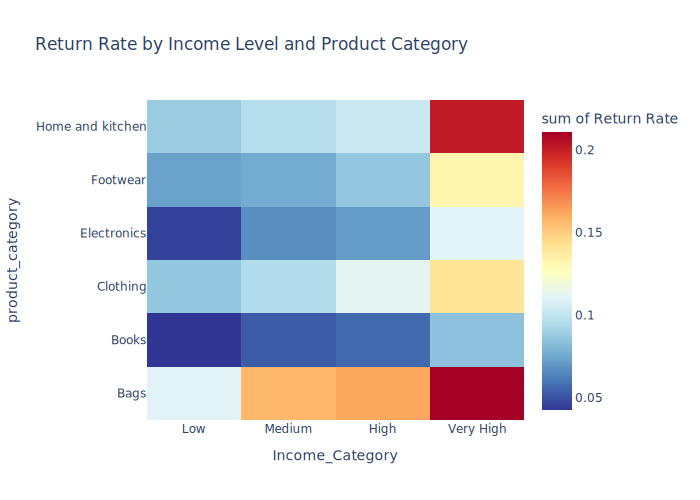

,Income_Category,product_category,Return
0,Low,Bags,0.110260
1,Low,Books,0.042589
2,Low,Clothing,0.085793
3,Low,Electronics,0.045455
4,Low,Footwear,0.072827
5,Low,Home and kitchen,0.087838
6,Medium,Bags,0.156986
7,Medium,Books,0.052356
8,Medium,Clothing,0.094977
9,Medium,Electronics,0.066998


In [46]:
# Plot heatmap
fig = px.density_heatmap(
    income_category_return,
    x="Income_Category",
    y="product_category",
    z="Return",
    color_continuous_scale="RdYlBu_r",
    title="Return Rate by Income Level and Product Category",
    labels={"Return": "Return Rate"}
)

fig.show()
income_category_return


### - Insight Summary:

-  **1- Very High income customers drive the highest return rates, particularly for Bags (up to 20%) and Home and Kitchen (18-20%), indicating their significant influence on returns.**

-  **2- Bags show elevated returns across Medium and Very High income levels, with the peak at 20% for Very High income, suggesting sensitivity to product quality or expectations.**

-  **3- Home and Kitchen returns surge to 18-20% for Very High income buyers, reflecting their critical role in this category.**

###  **- The data highlights that Very High income customers, as a sensitive and important category, are a key factor in driving returns, especially for Bags and Home and Kitchen.**


### - Recommendation Summary:

- **1-Recognize Very High income customers as an important segment and develop strategies to retain them, such as exclusive offers or better return handling.**


## 8- What is Return Rate by Tax Level for each Product Subcategory ?

In [47]:
df.Tax_Level.value_counts()

Tax_Level
Medium    9750
Low       4880
High      4874
Name: count, dtype: int64

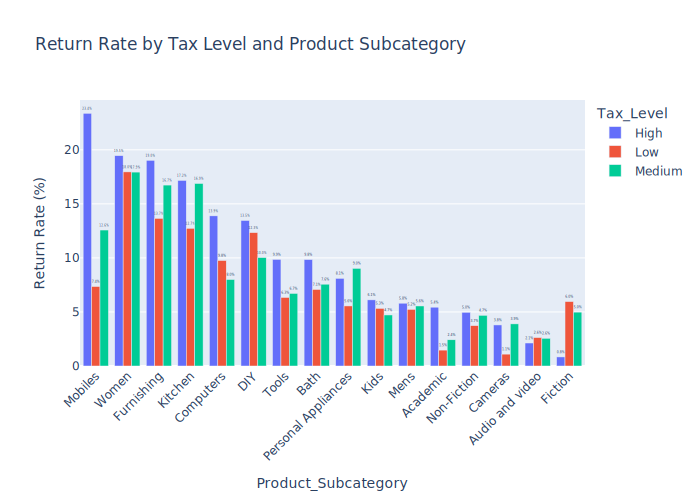

In [48]:
tax_sub_return = (
    df.groupby(["Tax_Level", "Product_Subcategory"])["Return"]
    .mean()
    .reset_index()
    .sort_values("Return", ascending=False)
)

# Convert Return rate to %
tax_sub_return["Return"] = tax_sub_return["Return"] * 100

# Plot as grouped bar chart
fig = px.bar(
    tax_sub_return,
    x="Product_Subcategory",
    y="Return",
    color="Tax_Level",
    barmode="group",
    text=tax_sub_return["Return"].round(1).astype(str) + '%',
    title="Return Rate by Tax Level and Product Subcategory",
    labels={"Return": "Return Rate (%)"}
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

### - Insight Summary:

-  **1- Mobiles under the highest tax level show the highest return rate by 24% for both, indicating a strong link between high tax and returns for this subcategory**

-  **2- Other subcategories like Women (19-20%) and Furnishing/Kitchen (15-19%) also have elevated returns under high tax**

-  **3- Women (19-20%) across all tax levels ، they have very big problem**

#### **- High tax level drives higher returns, especially for Mobiles and Women**

### - Recommendation Summary:

- **1-Focus on Mobiles with a 24% return rate under high tax—investigate quality issues or perceived value and consider tax relief or discounts.**

- **2-Launch a pilot with tax adjustments or enhanced warranties for Mobiles to reduce the 24% return rate.**




________________________________________________________________________________

## **Final Recommendations**



### Action Plan to Reduce Returns



-  **1-Focus on Women’s Bags: Fix the 59% return rate for low satisfaction by improving quality and fit. Add clear size guides and let customers try before buying.**



-  **2-Improve Women’s Clothing and Footwear: Cut the 55% and 52% returns for low satisfaction with better designs and easy return options. Offer fit advice in stores.**



-  **3-Boost Women’s Home and Kitchen: Lower the 50% return rate for low satisfaction by checking product quality and giving simple use instructions.**



-  **4-Help with Mobiles: Reduce the 24% return rate for low satisfaction in Electronics by offering strong warranties and quick tech support.**



-  **4-Target High Tax and Income Issues: For items like Mobiles (24% at high tax) and Bags (20% for Very High income), test lower taxes or discounts to keep customers happy.**



-  **5-Use Happy Customers: Learn from the 3% return rate with high satisfaction—share good designs and service tips across all products.**



-  **6-Start a Big Test: Run a pilot program with fit checks, surveys, and better support for low-satisfaction customers, especially for Women’s products and high-tax items, to find and fix problems fast.**



-  **7-Collect Data on Returned Products: Gather info from all returned items in every category using: surveys, logs, or feedback forms. Common causes include sizing/fit issues, damaged/defective products, unmet expectations, and shipping damage. Use this data to fix problems, such as better size guides for clothing/bags, stronger packaging for electronics/home items, and clear descriptions for books.**

In [49]:
# Drop temporary analysis columns created during EDA
df.drop(['Tax_Level', 'Review_Level', 'Income_Category'], axis=1, inplace=True, errors='ignore') 

In [50]:
# ── Save EDA-ready data for notebook 03 feature engineering ──────────────────────────────────────

df.reset_index(drop=True, inplace=True)
df.to_csv("data/02_eda_clean.csv", index=False)
print(f"Saved EDA-clean data → data/02_eda_clean.csv  |  shape: {df.shape}")

Saved EDA-clean data → data/02_eda_clean.csv  |  shape: (19504, 17)
